In [1]:
# import pytorch
import torch

import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import ToTensor, Lambda

import matplotlib.pyplot as plt
import numpy as np

import source.preprocessing as cheepre

In [2]:
import importlib; importlib.reload(cheepre)

<module 'source.preprocessing' from '/Users/m.wehrens/Documents/git_repos/_UVA/2025_Cheeky-cells/source/preprocessing.py'>

In [3]:
# Based on tutorial and notebook listed below
# https://pytorch.org/tutorials/beginner/basics/intro.html
# /Users/m.wehrens/Documents/git_repos/_UVA/2025_MW-testing-ML/simple-tutorial.ipynb



class CustomImageDataset(Dataset):
    def __init__(self, annot_dir, img_dir, transform=None, target_transform=None):
        
        self.annot_dir = annot_dir
        self.img_dir = img_dir
        
        # get dataset info
        annot_pixelcount_list, list_allimgpaths, list_annotfilepaths = cheepre.acquire_trainingset_info(img_dir, annot_dir)
        self.annot_pixelcount_list = annot_pixelcount_list
        self.img_list = list_allimgpaths
        self.img_annot_list = list_annotfilepaths
        
        # get dataset img_idx, locx, locy, label
        self.img_idxs, self.posis, self.posjs, self.labels = \
            cheepre.build_labels_and_positions(annot_dir, annot_pixelcount_list, list_allimgpaths, list_annotfilepaths)
        self.labels = self.labels.astype(int)
        
        # transforms        
        self.transform = transform
        self.target_transform = target_transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        
        # now produce the label and the image
        label = self.labels[idx]
        image = cheepre.provide_crop(self.img_dir, self.img_list[self.img_idxs[idx]], self.posis[idx], self.posjs[idx])
    
        # transform
        if self.transform:
            image = self.transform(image)
            
        if self.target_transform:
            label = self.target_transform(label)
            
        return image, label

In [4]:
%%capture
ANNOT_DIR = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/Cheeck-Cells_AnnotatedMW_resized_humanannotated/'
IMG_DIR   = '/Users/m.wehrens/Data_UVA/2024_07_Wang-cel/2025_Cells_preliminarybatch1/Cheeck-Cells_AnnotatedMW_resized_grey/'
mydataset = CustomImageDataset(annot_dir=ANNOT_DIR, 
                               img_dir=IMG_DIR, 
                               transform=ToTensor(), 
                               target_transform=Lambda(lambda y: torch.zeros(6, dtype=torch.float).scatter_(0, torch.tensor(y), value=1)))

Text(0.5, 1.0, 'label=2')

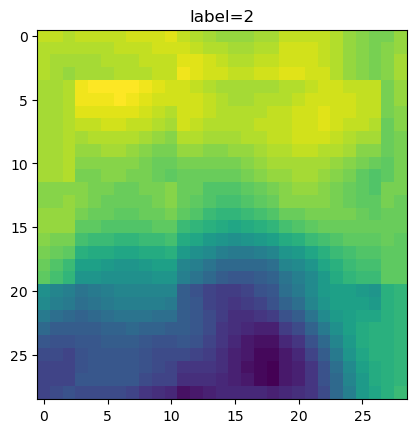

In [5]:


# show one of the images of "mydataset" above
#import matplotlib.pyplot as plt
#import numpy as np
#import random
#import torchvision.transforms.functional as TF

image, label = mydataset[0]

plt.imshow(image[0])
plt.title('label='+str(np.where(label)[0][0]))


In [6]:
# show size of "mydataset"
len(mydataset)

494732

In [7]:
# divide mydataset into 20% test set and 80% training set

from torch.utils.data import random_split

# Define the sizes of your splits
total_size = len(mydataset)
train_size = int(0.8 * total_size)  # 80% for training
val_size = total_size - train_size   # 20% for validation

# Create the splits
train_dataset, val_dataset = random_split(
    mydataset, 
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # For reproducibility
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)



In [8]:
# mydataset[1]

Feature batch shape: torch.Size([64, 1, 29, 29])
Labels batch shape: torch.Size([64, 6])


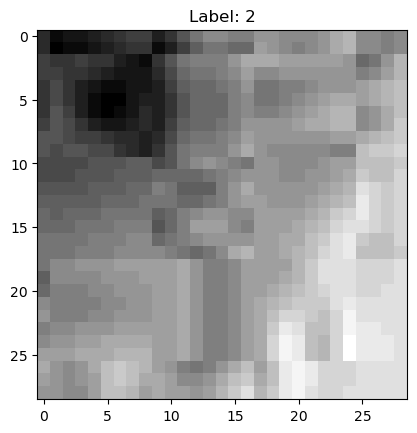

In [9]:
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img, cmap="gray")
plt.title(f"Label: {str(np.where(label)[0][0])}")
plt.show()
# print(f"Label: {str(np.where(label)[0][0])}")
#print(f"Label: {label} ({int(label.detach().cpu().numpy())})")

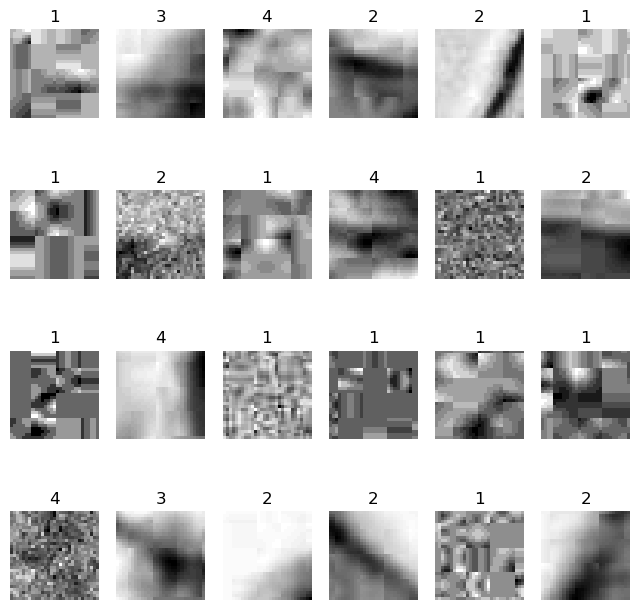

In [53]:
# train_dataset, val_dataset 

figure = plt.figure(figsize=(8, 8))
cols, rows = 6, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    # convert label to default python int
    label_det = str(label.argmax().detach().cpu().numpy())
    figure.add_subplot(rows, cols, i)
    plt.title(   label_det   )
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

# ({int(label.detach().cpu().numpy())})


# Now define the model (simple one from tutorial)

In [11]:
import os
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# get training device
device = "mps" if torch.backends.mps.is_available() else "cpu" # code is different from tutorial (fixed with co-pilot)
print(f"Using {device} device")

Using mps device


In [12]:
# Slightly adapted model from tutorial
# I have an input of 29*29 (original 28*28)
# And an output of 6 (original 10)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(29*29, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 6),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits
    
# So, the nn.Sequential will contain:
    # nn.Linear = fully connected dense neural network.
    # in these, there are neural notes which are connected to each node of the next layer
    # the value of the next node is determined by a simple weighed sum of all connected nodes
    # (plus a bias term); y = xW^T + b 
    #
    # nn.ReLu is something similar, but now an additional transform is applied to the 
    # initial weighed sum
    
# move model to the correct device
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=841, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=6, bias=True)
  )
)


In [13]:
# We can now already call the model

X = torch.rand(1, 29, 29, device=device) # random image as test input
logits = model(X) # "logits" refers to raw, unnormalized outputs of the final layer of a neural network
print('shape',logits.shape)
#pred_probab = nn.Softmax(dim=1)(logits) # converts output layer to probabilities
#print(f'Probabilities: {pred_probab}')
#y_pred = pred_probab.argmax(1) # finds the most likely label
#print(f"Predicted class: {y_pred}")

shape torch.Size([1, 6])


# Now train the model

In [14]:
model = NeuralNetwork()

In [15]:
# Hyperparameters

# Hyperparameters are not parameters that define the model, but parameters that 
# relate to finding the solution;
    # - numbers of epochs: number of times to iterate over the whole dataset
    # - batch size: (PB) typically the loss of multiple instances is calculated in 
    #   paralellel; the loss is then determined as L(L1, L2, L3, L_batchsize), typically just
    #   sum. The backward propagation needs to be called from a single scalar
    #   tensor; So you simply define L = L1 + L2 + L3 + L_batchsize, the tensor 
    #   concept allows then backpropagation on L, implicitly taking all L_i into
    #   account.
    # - learning rate: how much to update models parameters at each batch/epoc;
        # I'm guessing this is some factor sets the size of W updates.

learning_rate = 1e-3
batch_size = 64
epochs = 5

# We need to set loss function, and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
    # optimizer will actually implement some form of gradient descent

In [46]:
# The training loop is custom coded

TOTAL_SAMPLES     = 100_000
TOTAL_TESTSAMPLES = 10_000
NUM_TESTBATCHES = int(np.ceil(TOTAL_TESTSAMPLES/64))

def train_loop(dataloader, model, loss_fn, optimizer):
    
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            #print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
            print(f"loss: {loss:>7f}  [{current:>5d}/{TOTAL_SAMPLES:>5d}]")
            
        if (batch * batch_size + len(X)) > TOTAL_SAMPLES: # 100_000:
            print('Epoch done')
            break
            
def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = NUM_TESTBATCHES # len(dataloader)
    test_loss, correct = 0, 0
    
    print('Predicting for test set.')
    
    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for batch_idx, (X, y) in enumerate(dataloader):            
            
            if batch_idx>num_batches:
                break
            if batch_idx % 10 == 0:
                print(f'Batch {batch_idx}')
            
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            # correct += (pred.argmax(1) == y).type(torch.float).sum().item()
            correct += (y.argmax(1) == pred.argmax(1)).type(torch.float).sum().item()        

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [ ]:
# Now actually execute the training

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_loader, model, loss_fn, optimizer)
    test_loop(val_loader, model, loss_fn)
print("Done!")

# estimated training time:
# 25664 samples = 1:40 = 100 s
# ±40x as long --> 4000 seconds --> ±1hr 6min

Epoch 1
-------------------------------
loss: 1.346186  [   64/100000]
loss: 1.488151  [ 6464/100000]
loss: 1.351873  [12864/100000]
loss: 1.387357  [19264/100000]
loss: 1.442259  [25664/100000]
loss: 1.359523  [32064/100000]
loss: 1.286384  [38464/100000]
loss: 1.311555  [44864/100000]


In [ ]:
# test_loop(val_loader, model, loss_fn)
# test_loop(dataloader=val_loader, model, loss_fn)

dataloader=val_loader

model.eval()
size = len(dataloader.dataset)
num_batches = len(dataloader)
test_loss, correct = 0, 0

with torch.no_grad():
    for idx, (X, y) in enumerate(dataloader):
        pred = model(X)
        
        if idx>10:
            break
        test_loss += loss_fn(pred, y).item()
        correct += (y.argmax(1) == pred.argmax(1)).type(torch.float).sum().item()
        #correct += (pred.argmax(1) == y).type(torch.float).sum().item()


In [ ]:
pred.shape
pred.argmax(1)
pred.shape

torch.Size([64, 6])

In [ ]:
# (y==pred).any(1)
y.argmax(1) == pred.argmax(1)

tensor([False, False,  True, False, False,  True, False, False, False,  True,
         True, False, False,  True,  True, False, False, False, False,  True,
        False,  True, False, False,  True, False, False,  True, False, False,
        False, False, False, False, False, False,  True, False,  True, False,
        False, False, False, False, False, False, False,  True, False,  True,
        False, False, False,  True, False, False,  True,  True, False, False,
        False, False, False, False])

tensor([-0.0184,  0.1628,  0.1067,  0.0011,  0.0774,  0.1326])